In [1]:
# ============================================================
# Cell 1 : Imports
# ============================================================

import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Cell 2 : Configuration
# ============================================================

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 0

NUM_CLASSES = 14

EPOCHS = 20

LR = 1e-5

WEIGHT_DECAY = 1e-4


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device :", DEVICE)

Device : cuda


In [3]:
# ============================================================
# Cell 3 : Check Uploaded Model
# ============================================================

for root, dirs, files in os.walk("/kaggle/input/models"):

    print(root)

    for f in files:

        print("   ", f)

/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/supconn
/kaggle/input/models/swastikprakash/supconn/pytorch
/kaggle/input/models/swastikprakash/supconn/pytorch/default
/kaggle/input/models/swastikprakash/supconn/pytorch/default/1
    sample_embeddings.npy
    best_supcon_encoder.pth


In [4]:
# ============================================================
# Cell 4 : Disease Labels
# ============================================================

DISEASES = [

    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"

]

In [5]:
# ============================================================
# Cell 5 : Load Metadata
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

metadata = pd.read_csv(
    os.path.join(
        DATASET_PATH,
        "Data_Entry_2017.csv"
    )
)

metadata = metadata.drop(
    columns=["Unnamed: 11"],
    errors="ignore"
)

print(metadata.shape)

(112120, 11)


In [6]:
# ============================================================
# Cell 6 : Image Paths
# ============================================================

IMAGE_PATH_DICT = {}

image_files = glob(
    os.path.join(
        DATASET_PATH,
        "images_*",
        "images",
        "*.png"
    )
)

for img in image_files:

    IMAGE_PATH_DICT[
        os.path.basename(img)
    ] = img

metadata["Image Path"] = metadata[
    "Image Index"
].map(
    IMAGE_PATH_DICT
)

metadata = metadata.dropna().reset_index(drop=True)

print(metadata.shape)

(112120, 12)


In [7]:
# ============================================================
# Cell 7 : Multi-label Encoding
# ============================================================

for disease in DISEASES:

    metadata[disease] = metadata[
        "Finding Labels"
    ].apply(

        lambda x: int(
            disease in x.split("|")
        )

    )

metadata.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,1,0,0,0,0,0,0


In [8]:
# ============================================================
# Cell 8 : Patient-wise Train / Validation / Test Split
# ============================================================

# -------- First Split (70% Train, 30% Temp) --------

gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(
        metadata,
        groups=metadata["Patient ID"]
    )
)

train_df = metadata.iloc[train_idx].reset_index(drop=True)

temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

# -------- Second Split (20% Val, 10% Test) --------
# temp = 30%
# val = 20/30 = 0.6667 of temp
# test = 10/30 = 0.3333 of temp

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=2/3,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("="*60)
print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")
print("="*60)

Train      : 78566
Validation : 22204
Test       : 11350


In [9]:
# ============================================================
# Cell 9 : CLAHE
# ============================================================

def apply_clahe(image):

    clahe = cv2.createCLAHE(

        clipLimit=2,

        tileGridSize=(8,8)

    )

    return clahe.apply(image)

In [10]:
# ============================================================
# Cell 10 : Transform
# ============================================================

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [11]:
# ============================================================
# Cell 11 : Dataset
# ============================================================

class NIHArcFaceDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(

            row["Image Path"],

            cv2.IMREAD_GRAYSCALE

        )

        image = apply_clahe(image)

        image = cv2.cvtColor(

            image,

            cv2.COLOR_GRAY2RGB

        )

        image = transform(image)

        label = row[
            DISEASES
        ].values.astype(np.float32)

        return image, torch.tensor(label)

In [12]:
# ============================================================
# Cell 12 : DataLoaders
# ============================================================

train_dataset = NIHArcFaceDataset(train_df)

val_dataset = NIHArcFaceDataset(val_df)

test_dataset = NIHArcFaceDataset(test_df)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True

)


print("="*60)
print(f"Train Images      : {len(train_dataset)}")
print(f"Validation Images : {len(val_dataset)}")
print(f"Test Images       : {len(test_dataset)}")
print("-"*60)
print(f"Train Batches      : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Test Batches       : {len(test_loader)}")
print("="*60)

Train Images      : 78566
Validation Images : 22204
Test Images       : 11350
------------------------------------------------------------
Train Batches      : 2456
Validation Batches : 694
Test Batches       : 355


In [13]:
# ============================================================
# Cell 13 : Build ConvNeXt Encoder
# ============================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

backbone = convnext_tiny(weights=weights)

in_features = backbone.classifier[2].in_features

backbone.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

backbone = backbone.to(DEVICE)

print(backbone.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 214MB/s]


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=14, bias=True)
)


In [14]:
# ============================================================
# Cell 14 : Load SupCon Model
# ============================================================

MODEL_PATH = "/kaggle/input/models/swastikprakash/supconn/pytorch/default/1/best_supcon_encoder.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("="*60)
print("Checkpoint Loaded Successfully")
print("="*60)

print(checkpoint.keys())

Checkpoint Loaded Successfully
dict_keys(['encoder_state_dict', 'projection_head_state_dict', 'optimizer_state_dict', 'loss', 'epoch'])


In [15]:
# ============================================================
# Cell 15 : Feature Extractor
# ============================================================

class ConvNeXtFeatureExtractor(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.features = backbone.features
        self.avgpool = backbone.avgpool

    def forward(self, x):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(x,1)

        return x


encoder = ConvNeXtFeatureExtractor(
    backbone
).to(DEVICE)

In [16]:
# ============================================================
# Cell 16 : Restore SupCon Encoder
# ============================================================

encoder.load_state_dict(
    checkpoint["encoder_state_dict"]
)

encoder.eval()

print("="*60)
print("SupCon Encoder Loaded")
print("="*60)

SupCon Encoder Loaded


In [17]:
# ============================================================
# Cell 17 : Verify Embeddings
# ============================================================

dummy = torch.randn(
    8,
    3,
    224,
    224
).to(DEVICE)

with torch.no_grad():

    emb = encoder(dummy)

print("="*60)

print("Embedding Shape :", emb.shape)

print("="*60)

Embedding Shape : torch.Size([8, 768])


In [18]:
# ============================================================
# Cell 18 : ArcFace Layer
# ============================================================

class ArcMarginProduct(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 s=30.0,
                 m=0.50):

        super().__init__()

        self.s = s
        self.m = m

        self.weight = nn.Parameter(
            torch.FloatTensor(
                out_features,
                in_features
            )
        )

        nn.init.xavier_uniform_(self.weight)

    def forward(self, features):

        features = F.normalize(
            features
        )

        weight = F.normalize(
            self.weight
        )

        cosine = F.linear(
            features,
            weight
        )

        cosine = torch.clamp(
            cosine,
            -1 + 1e-7,
            1 - 1e-7
        )

        theta = torch.acos(cosine)

        logits = torch.cos(
            theta + self.m
        )

        logits *= self.s

        return logits

In [19]:
# ============================================================
# Cell 19 : ArcFace Model
# ============================================================

class ArcFaceModel(nn.Module):

    def __init__(self,
                 encoder):

        super().__init__()

        self.encoder = encoder

        self.arcface = ArcMarginProduct(

            768,

            NUM_CLASSES

        )

    def forward(self,x):

        embedding = self.encoder(x)

        logits = self.arcface(embedding)

        return embedding, logits


arcface_model = ArcFaceModel(
    encoder
).to(DEVICE)

print(arcface_model)

ArcFaceModel(
  (encoder): ConvNeXtFeatureExtractor(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2)

In [20]:
# ============================================================
# Cell 19A : Progressive Fine-Tuning Setup
# ============================================================

# Freeze entire encoder first

for param in arcface_model.encoder.parameters():
    param.requires_grad = False

# Unfreeze only the last ConvNeXt stage

for param in arcface_model.encoder.features[7].parameters():
    param.requires_grad = True

# ArcFace layer should always be trainable

for param in arcface_model.arcface.parameters():
    param.requires_grad = True

print("="*60)

print("Progressive Fine-Tuning Enabled")

print("Frozen : ConvNeXt Stages 0-6")

print("Trainable : Stage 7 + ArcFace")

print("="*60)

trainable = sum(
    p.numel()
    for p in arcface_model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in arcface_model.parameters()
)

print(f"Trainable Parameters : {trainable:,}")

print(f"Total Parameters     : {total:,}")

Progressive Fine-Tuning Enabled
Frozen : ConvNeXt Stages 0-6
Trainable : Stage 7 + ArcFace
Trainable Parameters : 14,300,160
Total Parameters     : 27,829,344


In [21]:
# ============================================================
# Cell 20 : Verify ArcFace
# ============================================================

dummy = torch.randn(
    4,
    3,
    224,
    224
).to(DEVICE)

with torch.no_grad():

    embedding, logits = arcface_model(
        dummy
    )

print("="*60)

print("Embedding :", embedding.shape)

print("Logits :", logits.shape)

print("="*60)

Embedding : torch.Size([4, 768])
Logits : torch.Size([4, 14])


In [22]:
# ============================================================
# Cell 21 : Loss Function (Circle Loss + OHEM BCE)
# ============================================================
import torch.nn.functional as F

class MultiLabelCircleLoss(nn.Module):
    def __init__(self, m=0.25, gamma=80):
        super().__init__()
        self.m = m
        self.gamma = gamma
    def forward(self, logits, labels):
        alpha_p = torch.clamp_min(-logits.detach() + 1 + self.m, min=0.)
        alpha_n = torch.clamp_min(logits.detach() + self.m, min=0.)
        loss_p = F.softplus(-self.gamma * alpha_p * (logits - self.m))
        loss_n = F.softplus(self.gamma * alpha_n * (logits + self.m))
        loss = labels * loss_p + (1 - labels) * loss_n
        return loss.mean(dim=1)

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
        self.circle = MultiLabelCircleLoss()
    def forward(self, logits, labels):
        # OHEM BCE
        bce_loss = self.bce(logits, labels).mean(dim=1)
        # Circle Loss
        circle_loss = self.circle(logits, labels)
        total_loss = bce_loss + 0.5 * circle_loss
        # Hard Negative Mining (Top 75%)
        k = max(1, int(total_loss.size(0) * 0.75))
        hard_loss, _ = torch.topk(total_loss, k)
        return hard_loss.mean()

criterion = CombinedLoss()
print("Loss Function : Combined Circle Loss + OHEM BCE")


Loss Function : Combined Circle Loss + OHEM BCE


In [23]:
# ============================================================
# Cell 22 : Optimizer (Progressive Fine-Tuning)
# ============================================================

optimizer = torch.optim.AdamW(

    [

        {

            "params": arcface_model.encoder.features[7].parameters(),

            "lr": 1e-6

        },

        {

            "params": arcface_model.arcface.parameters(),

            "lr": 1e-4

        }

    ],

    weight_decay=1e-4

)

print("="*60)

print("Optimizer Ready")

print("Encoder LR :", 1e-6)

print("ArcFace LR :", 1e-4)

print("="*60)

Optimizer Ready
Encoder LR : 1e-06
ArcFace LR : 0.0001


In [24]:
# ============================================================
# Cell 23 : Scheduler
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20,

    eta_min=1e-7

)

print("Scheduler Ready")

Scheduler Ready


In [25]:
# ============================================================
# Cell 24 : Mixed Precision
# ============================================================

scaler = torch.cuda.amp.GradScaler()

print("AMP Enabled")

AMP Enabled


In [26]:
# ============================================================
# Cell 25A : Model Information
# ============================================================

total_params = sum(
    p.numel()
    for p in arcface_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in arcface_model.parameters()
    if p.requires_grad
)

print("="*60)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print("="*60)

Total Parameters     : 27,829,344
Trainable Parameters : 14,300,160


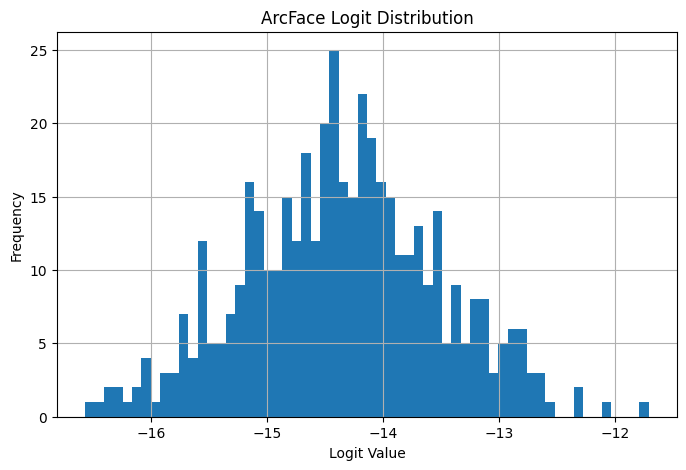

In [27]:
# ============================================================
# Cell 25B : Logit Distribution
# ============================================================

arcface_model.eval()

images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    _, logits = arcface_model(images)

logits = logits.cpu().numpy().flatten()

plt.figure(figsize=(8,5))

plt.hist(
    logits,
    bins=60
)

plt.title("ArcFace Logit Distribution")

plt.xlabel("Logit Value")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

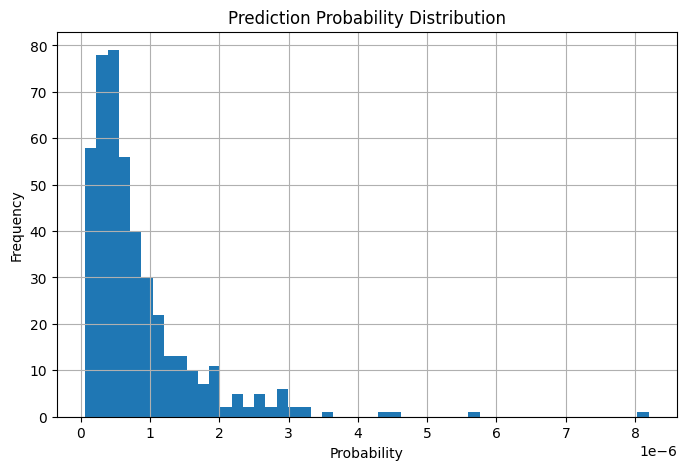

In [28]:
# ============================================================
# Cell 25C : Sigmoid Probability Distribution
# ============================================================

probs = torch.sigmoid(
    torch.tensor(logits)
).numpy()

plt.figure(figsize=(8,5))

plt.hist(
    probs,
    bins=50
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [29]:
# ============================================================
# Cell 25D : Embedding Statistics
# ============================================================

arcface_model.eval()

with torch.no_grad():

    embedding, _ = arcface_model(images)

embedding = embedding.cpu().numpy()

print("="*60)

print("Embedding Shape :", embedding.shape)

print("Mean :", embedding.mean())

print("Std :", embedding.std())

print("Min :", embedding.min())

print("Max :", embedding.max())

print("="*60)

Embedding Shape : (32, 768)
Mean : 0.0038933048
Std : 0.1269782
Min : -1.0202081
Max : 1.7087181


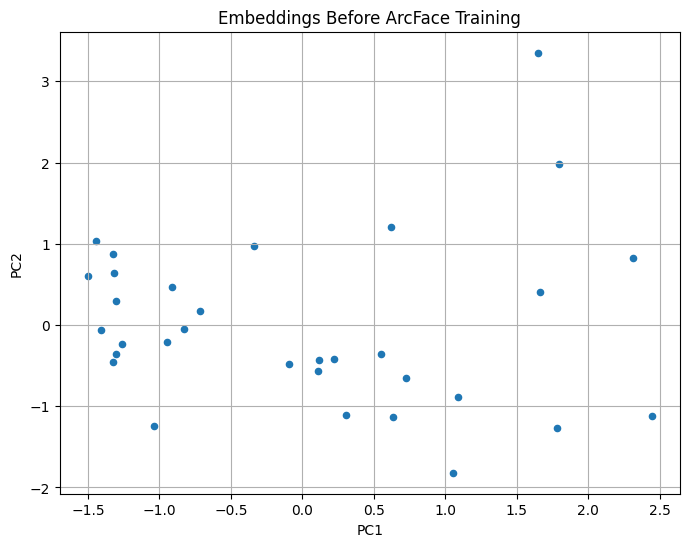

In [30]:
# ============================================================
# Cell 25E : PCA Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_2d = pca.fit_transform(embedding)

plt.figure(figsize=(8,6))

plt.scatter(

    embedding_2d[:,0],

    embedding_2d[:,1],

    s=20

)

plt.title("Embeddings Before ArcFace Training")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid(True)

plt.show()

In [31]:
# ============================================================
# Cell 27 : Train One Epoch
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

def train_one_epoch(
        model,
        loader,
        optimizer,
        criterion):

    model.train()

    running_loss = 0

    all_labels = []
    all_probs = []

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            _, logits = model(images)

            # CombinedLoss already includes:
            # BCE + Circle Loss + OHEM
            loss = criterion(
                logits,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(logits)

        all_labels.append(labels.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_probs).numpy()

    preds = (y_prob > 0.5).astype(int)

    metrics = {

        "loss": running_loss / len(loader),

        "auc": roc_auc_score(
            y_true,
            y_prob,
            average="macro"
        ),

        "f1": f1_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision": precision_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        )

    }

    return metrics

In [32]:
# ============================================================
# Cell 28 : Validation
# ============================================================

def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0

    all_labels = []

    all_probs = []

    with torch.no_grad():

        for images,labels in tqdm(loader):

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            _,logits = model(images)

            loss = criterion.bce(logits, labels).mean() + 0.5 * criterion.circle(logits, labels).mean()

            running_loss += loss.item()

            probs = torch.sigmoid(logits)

            all_labels.append(labels.cpu())

            all_probs.append(probs.cpu())

    y_true = torch.cat(all_labels).numpy()

    y_prob = torch.cat(all_probs).numpy()

    preds = (y_prob>0.5).astype(int)

    metrics = {

        "loss":running_loss/len(loader),

        "auc":roc_auc_score(
            y_true,
            y_prob,
            average="macro"
        ),

        "f1":f1_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision":precision_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall":recall_score(
            y_true,
            preds,
            average="macro",
            zero_division=0
        )

    }

    return metrics

In [33]:
# ============================================================
# Cell 29 : Training Configuration
# ============================================================

EPOCHS = 20

BEST_AUC = 0

PATIENCE = 5

counter = 0

SAVE_PATH = "/kaggle/working/best_arcface_model.pth"

history = {

    "train_loss":[],

    "val_loss":[],

    "train_auc":[],

    "val_auc":[],

    "train_f1":[],

    "val_f1":[],

    "train_precision":[],

    "val_precision":[],

    "train_recall":[],

    "val_recall":[]

}

print("Training Configuration Ready")

Training Configuration Ready


In [34]:
# ============================================================
# Cell 30 : ArcFace Training
# ============================================================

import time

start_time = time.time()

for epoch in range(EPOCHS):

    print("\n" + "="*80)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("="*80)

    # --------------------------------------------------------
    # Progressive Unfreezing
    # --------------------------------------------------------

    if epoch == 5 and not stage6_unfrozen:
    
        print("\n[Progressive Unfreezing] Unfreezing ConvNeXt Stage 6")
    
        for param in arcface_model.encoder.features[6].parameters():
            param.requires_grad = True
    
        optimizer.add_param_group(
            {
                "params": arcface_model.encoder.features[6].parameters(),
                "lr": 5e-7
            }
        )
    
        stage6_unfrozen = True
    
    elif epoch == 10 and not stage5_unfrozen:
    
        print("\n[Progressive Unfreezing] Unfreezing ConvNeXt Stage 5")
    
        for param in arcface_model.encoder.features[5].parameters():
            param.requires_grad = True
    
        optimizer.add_param_group(
            {
                "params": arcface_model.encoder.features[5].parameters(),
                "lr": 1e-7
            }
        )

        stage5_unfrozen = True
    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = train_one_epoch(

        arcface_model,

        train_loader,

        optimizer,

        criterion

    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = validate(

        arcface_model,

        val_loader,

        criterion

    )

    scheduler.step()

    # --------------------------------------------------------
    # Save History
    # --------------------------------------------------------

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])

    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])

    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])

    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])

    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    # --------------------------------------------------------
    # Print Metrics
    # --------------------------------------------------------

    print(f"Train Loss      : {train_metrics['loss']:.4f}")
    print(f"Validation Loss : {val_metrics['loss']:.4f}")

    print(f"Train AUROC     : {train_metrics['auc']:.4f}")
    print(f"Validation AUROC: {val_metrics['auc']:.4f}")

    print(f"Train F1        : {train_metrics['f1']:.4f}")
    print(f"Validation F1   : {val_metrics['f1']:.4f}")

    print(f"Train Precision : {train_metrics['precision']:.4f}")
    print(f"Validation Prec.: {val_metrics['precision']:.4f}")

    print(f"Train Recall    : {train_metrics['recall']:.4f}")
    print(f"Validation Rec. : {val_metrics['recall']:.4f}")

    # --------------------------------------------------------
    # Save Best Model
    # --------------------------------------------------------

    if val_metrics["auc"] > BEST_AUC:

        BEST_AUC = val_metrics["auc"]

        counter = 0

        torch.save(

            {

                "model_state_dict": arcface_model.state_dict(),

                "optimizer_state_dict": optimizer.state_dict(),

                "scheduler_state_dict": scheduler.state_dict(),

                "history": history,

                "best_auc": BEST_AUC,

                "epoch": epoch

            },

            SAVE_PATH

        )

        print("\n✅ Best ArcFace Model Saved")

    else:

        counter += 1

        print(f"\nNo Improvement ({counter}/{PATIENCE})")

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    if counter >= PATIENCE:

        print("\n🛑 Early Stopping Triggered")

        break


training_time = (time.time() - start_time) / 60

print("\n" + "="*80)

print("🎉 ArcFace Training Completed")

print(f"Best Validation AUROC : {BEST_AUC:.4f}")

print(f"Training Time         : {training_time:.2f} minutes")

print(f"Model Saved At        : {SAVE_PATH}")

print("="*80)


Epoch [1/20]


  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  0%|          | 0/694 [00:00<?, ?it/s]

Train Loss      : 113.3947
Validation Loss : 13.8464
Train AUROC     : 0.6848
Validation AUROC: 0.7933
Train F1        : 0.2085
Validation F1   : 0.2483
Train Precision : 0.2642
Validation Prec.: 0.1824
Train Recall    : 0.1766
Validation Rec. : 0.3993

✅ Best ArcFace Model Saved

Epoch [2/20]


...

  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  0%|          | 0/694 [00:00<?, ?it/s]

Train Loss      : 4.1045
Validation Loss : 4.6488
Train AUROC     : 0.8892
Validation AUROC: 0.7914
Train F1        : 0.3959
Validation F1   : 0.2635
Train Precision : 0.3155
Validation Prec.: 0.2036
Train Recall    : 0.5416
Validation Rec. : 0.4042

No Improvement (4/5)

Epoch [6/20]


NameError: name 'stage6_unfrozen' is not defined

In [ ]:
# ============================================================
# Cell 31 : Load Best ArcFace Model
# ============================================================

checkpoint = torch.load(
    SAVE_PATH,
    map_location=DEVICE,
    weights_only=False
)

arcface_model.load_state_dict(
    checkpoint["model_state_dict"]
)

arcface_model.eval()

print("="*60)
print("Best ArcFace Model Loaded")
print(f"Best AUROC : {checkpoint['best_auc']:.4f}")
print("="*60)

In [ ]:
# ============================================================
# Cell 32 : Test Evaluation
# ============================================================

test_metrics = validate(
    arcface_model,
    test_loader,
    criterion
)

print("="*70)
print("TEST RESULTS")
print("="*70)

print(f"Loss      : {test_metrics['loss']:.4f}")
print(f"AUROC     : {test_metrics['auc']:.4f}")
print(f"F1 Score  : {test_metrics['f1']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")

print("="*70)

In [ ]:
# ============================================================
# Cell 33 : Loss Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"],label="Train")

plt.plot(history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Cell 34 : AUROC
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_auc"],label="Train")

plt.plot(history["val_auc"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("AUROC")

plt.title("Training vs Validation AUROC")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Cell 35 : F1 Score
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_f1"],label="Train")

plt.plot(history["val_f1"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("F1")

plt.title("Training vs Validation F1")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Cell 36 : Precision
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_precision"],label="Train")

plt.plot(history["val_precision"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Precision")

plt.title("Training vs Validation Precision")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Cell 37 : Recall
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_recall"],label="Train")

plt.plot(history["val_recall"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Recall")

plt.title("Training vs Validation Recall")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# Cell 38 : Predictions
# ============================================================

arcface_model.eval()

all_labels=[]

all_probs=[]

with torch.no_grad():

    for images,labels in tqdm(test_loader):

        images=images.to(DEVICE)

        labels=labels.to(DEVICE)

        _,logits=arcface_model(images)

        probs=torch.sigmoid(logits)

        all_labels.append(labels.cpu())

        all_probs.append(probs.cpu())

y_true=torch.cat(all_labels).numpy()

y_prob=torch.cat(all_probs).numpy()

y_pred=(y_prob>0.5).astype(int)

print(y_true.shape)

print(y_pred.shape)

In [ ]:
# ============================================================
# Cell 39 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(

classification_report(

y_true,

y_pred,

target_names=DISEASES,

zero_division=0

)

)

In [ ]:
# ============================================================
# Cell 40 : Confusion Matrix
# ============================================================

from sklearn.metrics import multilabel_confusion_matrix

cms=multilabel_confusion_matrix(y_true,y_pred)

for i,disease in enumerate(DISEASES):

    print("="*50)

    print(disease)

    print(cms[i])

In [ ]:
# ============================================================
# Cell 41 : Disease-wise AUROC
# ============================================================

print("="*60)

for i,disease in enumerate(DISEASES):

    auc=roc_auc_score(

        y_true[:,i],

        y_prob[:,i]

    )

    print(f"{disease:20s}: {auc:.4f}")

In [ ]:
# ============================================================
# Cell 42 : Final Save
# ============================================================

torch.save(

arcface_model.state_dict(),

"/kaggle/working/final_arcface_model.pth"

)

print("="*60)

print("Final ArcFace Model Saved")

print("/kaggle/working/final_arcface_model.pth")

print("="*60)